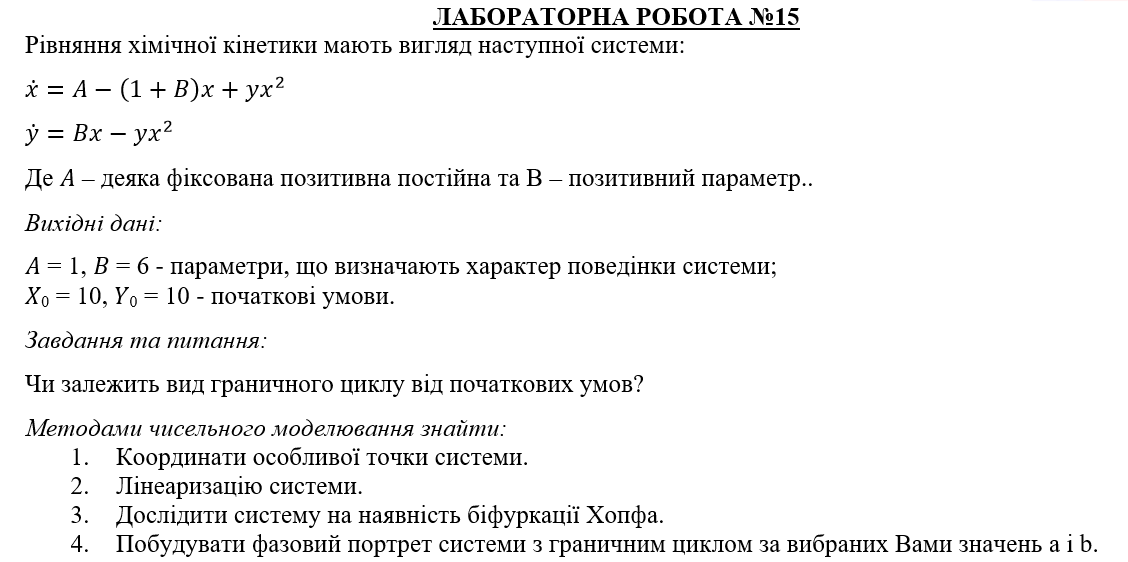

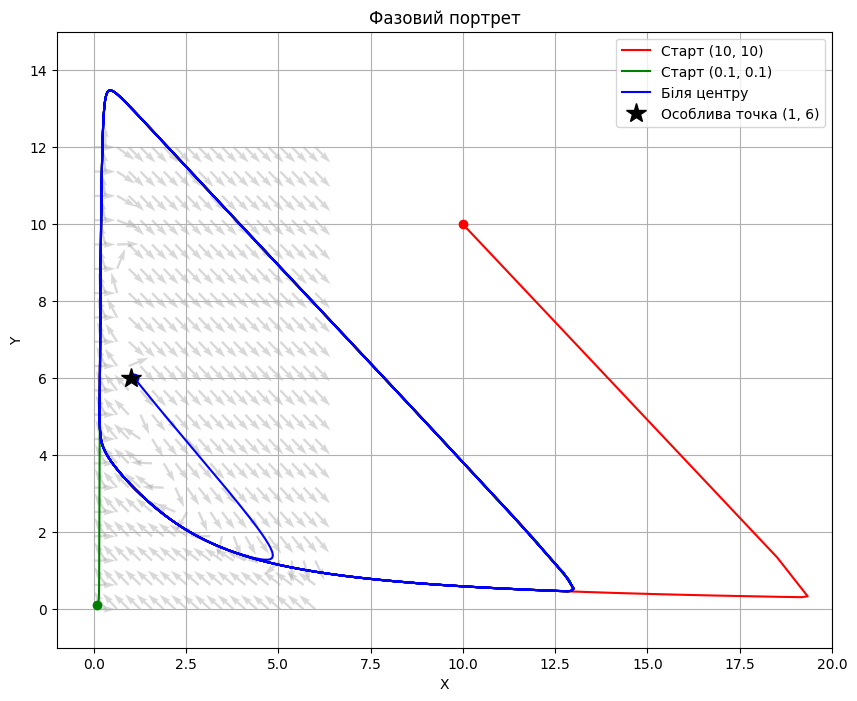

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Параметри (А - фіксована, B - варіюється)
A = 1.0
B = 6.0

# Система рівнянь
def system(t, state):
    x, y = state
    dxdt = A - (1 + B) * x + y * (x**2)
    dydt = B * x - y * (x**2)
    return [dxdt, dydt]

# Особлива точка
x_fixed = A
y_fixed = B / A

# Моделювання
t_span = (0, 50)  # Час моделювання
t_eval = np.linspace(0, 50, 5000)

# Різні початкові умови для перевірки залежності циклу
initial_conditions = [
    [10.0, 10.0],  # Задані в умові (зовнішні)
    [0.1, 0.1],    # Малі (внутрішні)
    [x_fixed + 0.1, y_fixed] # Дуже близько до центру
]

colors = ['r', 'g', 'b']
labels = ['Старт (10, 10)', 'Старт (0.1, 0.1)', 'Біля центру']

plt.figure(figsize=(10, 8))

# Побудова траєкторій
for i, ic in enumerate(initial_conditions):
    sol = solve_ivp(system, t_span, ic, t_eval=t_eval, rtol=1e-9, atol=1e-9)
    plt.plot(sol.y[0], sol.y[1], color=colors[i], label=labels[i], linewidth=1.5)
    plt.plot(ic[0], ic[1], 'o', color=colors[i])

# Побудова векторного поля
x_range = np.linspace(0, 6, 20)
y_range = np.linspace(0, 12, 20)
X, Y = np.meshgrid(x_range, y_range)

U = A - (1 + B) * X + Y * (X**2)
V = B * X - Y * (X**2)

# Нормалізація стрілок
N = np.sqrt(U**2 + V**2)
N[N == 0] = 1
plt.quiver(X, Y, U/N, V/N, color='gray', alpha=0.3)

# Позначення особливої точки
plt.plot(x_fixed, y_fixed, 'k*', markersize=15, label='Особлива точка (1, 6)')

# Оформлення графіка
plt.title(f'Фазовий портрет')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.xlim(-1, 20)
plt.ylim(-1, 15)

plt.show()